In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cuml

IMPORTING DATASETS

In [2]:
data = '/media/phoenix/SSD_2/Online course/Python/Project/Datasets/pbmc33k_filtered_gene_bc_matrices/filtered_gene_bc_matrices/hg19/'

In [3]:
adata = sc.read_10x_mtx(
    data,
    var_names = 'gene_symbols',
    cache = True
)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 33148 × 32738
    var: 'gene_ids'
    layers: None (.X)


In [4]:
fork_data = adata

SCALING \ NORMALIZING DATA

In [5]:
sc.pp.highly_variable_genes(
    adata,
    flavor = 'seurat_v3',
    n_top_genes = 2000
)

In [6]:
sc.pp.normalize_total(adata, target_sum = 10000)

In [7]:
sc.pp.log1p(adata)

In [8]:
adata = adata[:, adata.var.highly_variable]

In [9]:
print(adata)

View of AnnData object with n_obs × n_vars = 33148 × 2000
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    layers: None (.X)


In [10]:
adata.raw = adata

In [11]:
sc.pp.scale(adata,max_value = 10)

/home/phoenix/anaconda3/envs/cu-gpu/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PERFORMING PCA

In [12]:
sc.tl.pca(adata, svd_solver = 'arpack')

In [13]:
print(adata)

AnnData object with n_obs × n_vars = 33148 × 2000
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: None (.X)


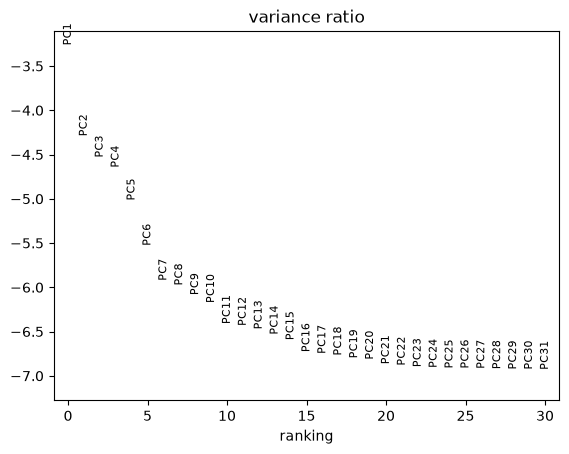

In [14]:
sc.pl.pca_variance_ratio(adata, log = 1)

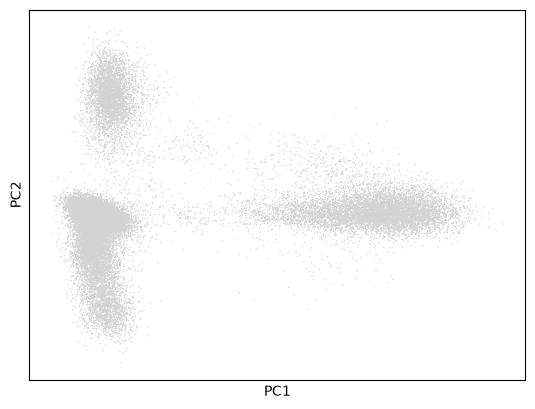

In [15]:
sc.pl.pca(adata)

CLUSTERING DATA BASED ON GENE EXPRESSION

In [16]:
sc.pp.neighbors(
    adata,
    n_neighbors = 10,
    n_pcs = 15
)

/home/phoenix/anaconda3/envs/cu-gpu/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
sc.tl.leiden(adata, resolution = 0.5)

/tmp/ipykernel_57187/3246266323.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution = 0.5)


In [18]:
sc.tl.umap(adata)

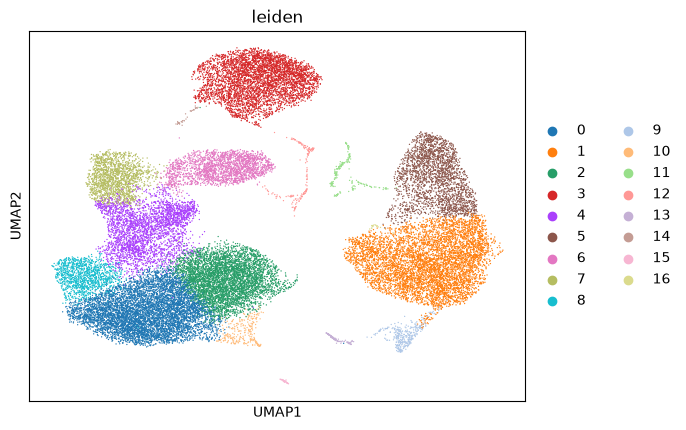

In [19]:
sc.pl.umap(adata, color = ['leiden'])

FINDING DOMINANT GENE OF EACH CLUSTER

In [20]:
sc.tl.rank_genes_groups(adata, 'leiden', method = 'wilcoxon')

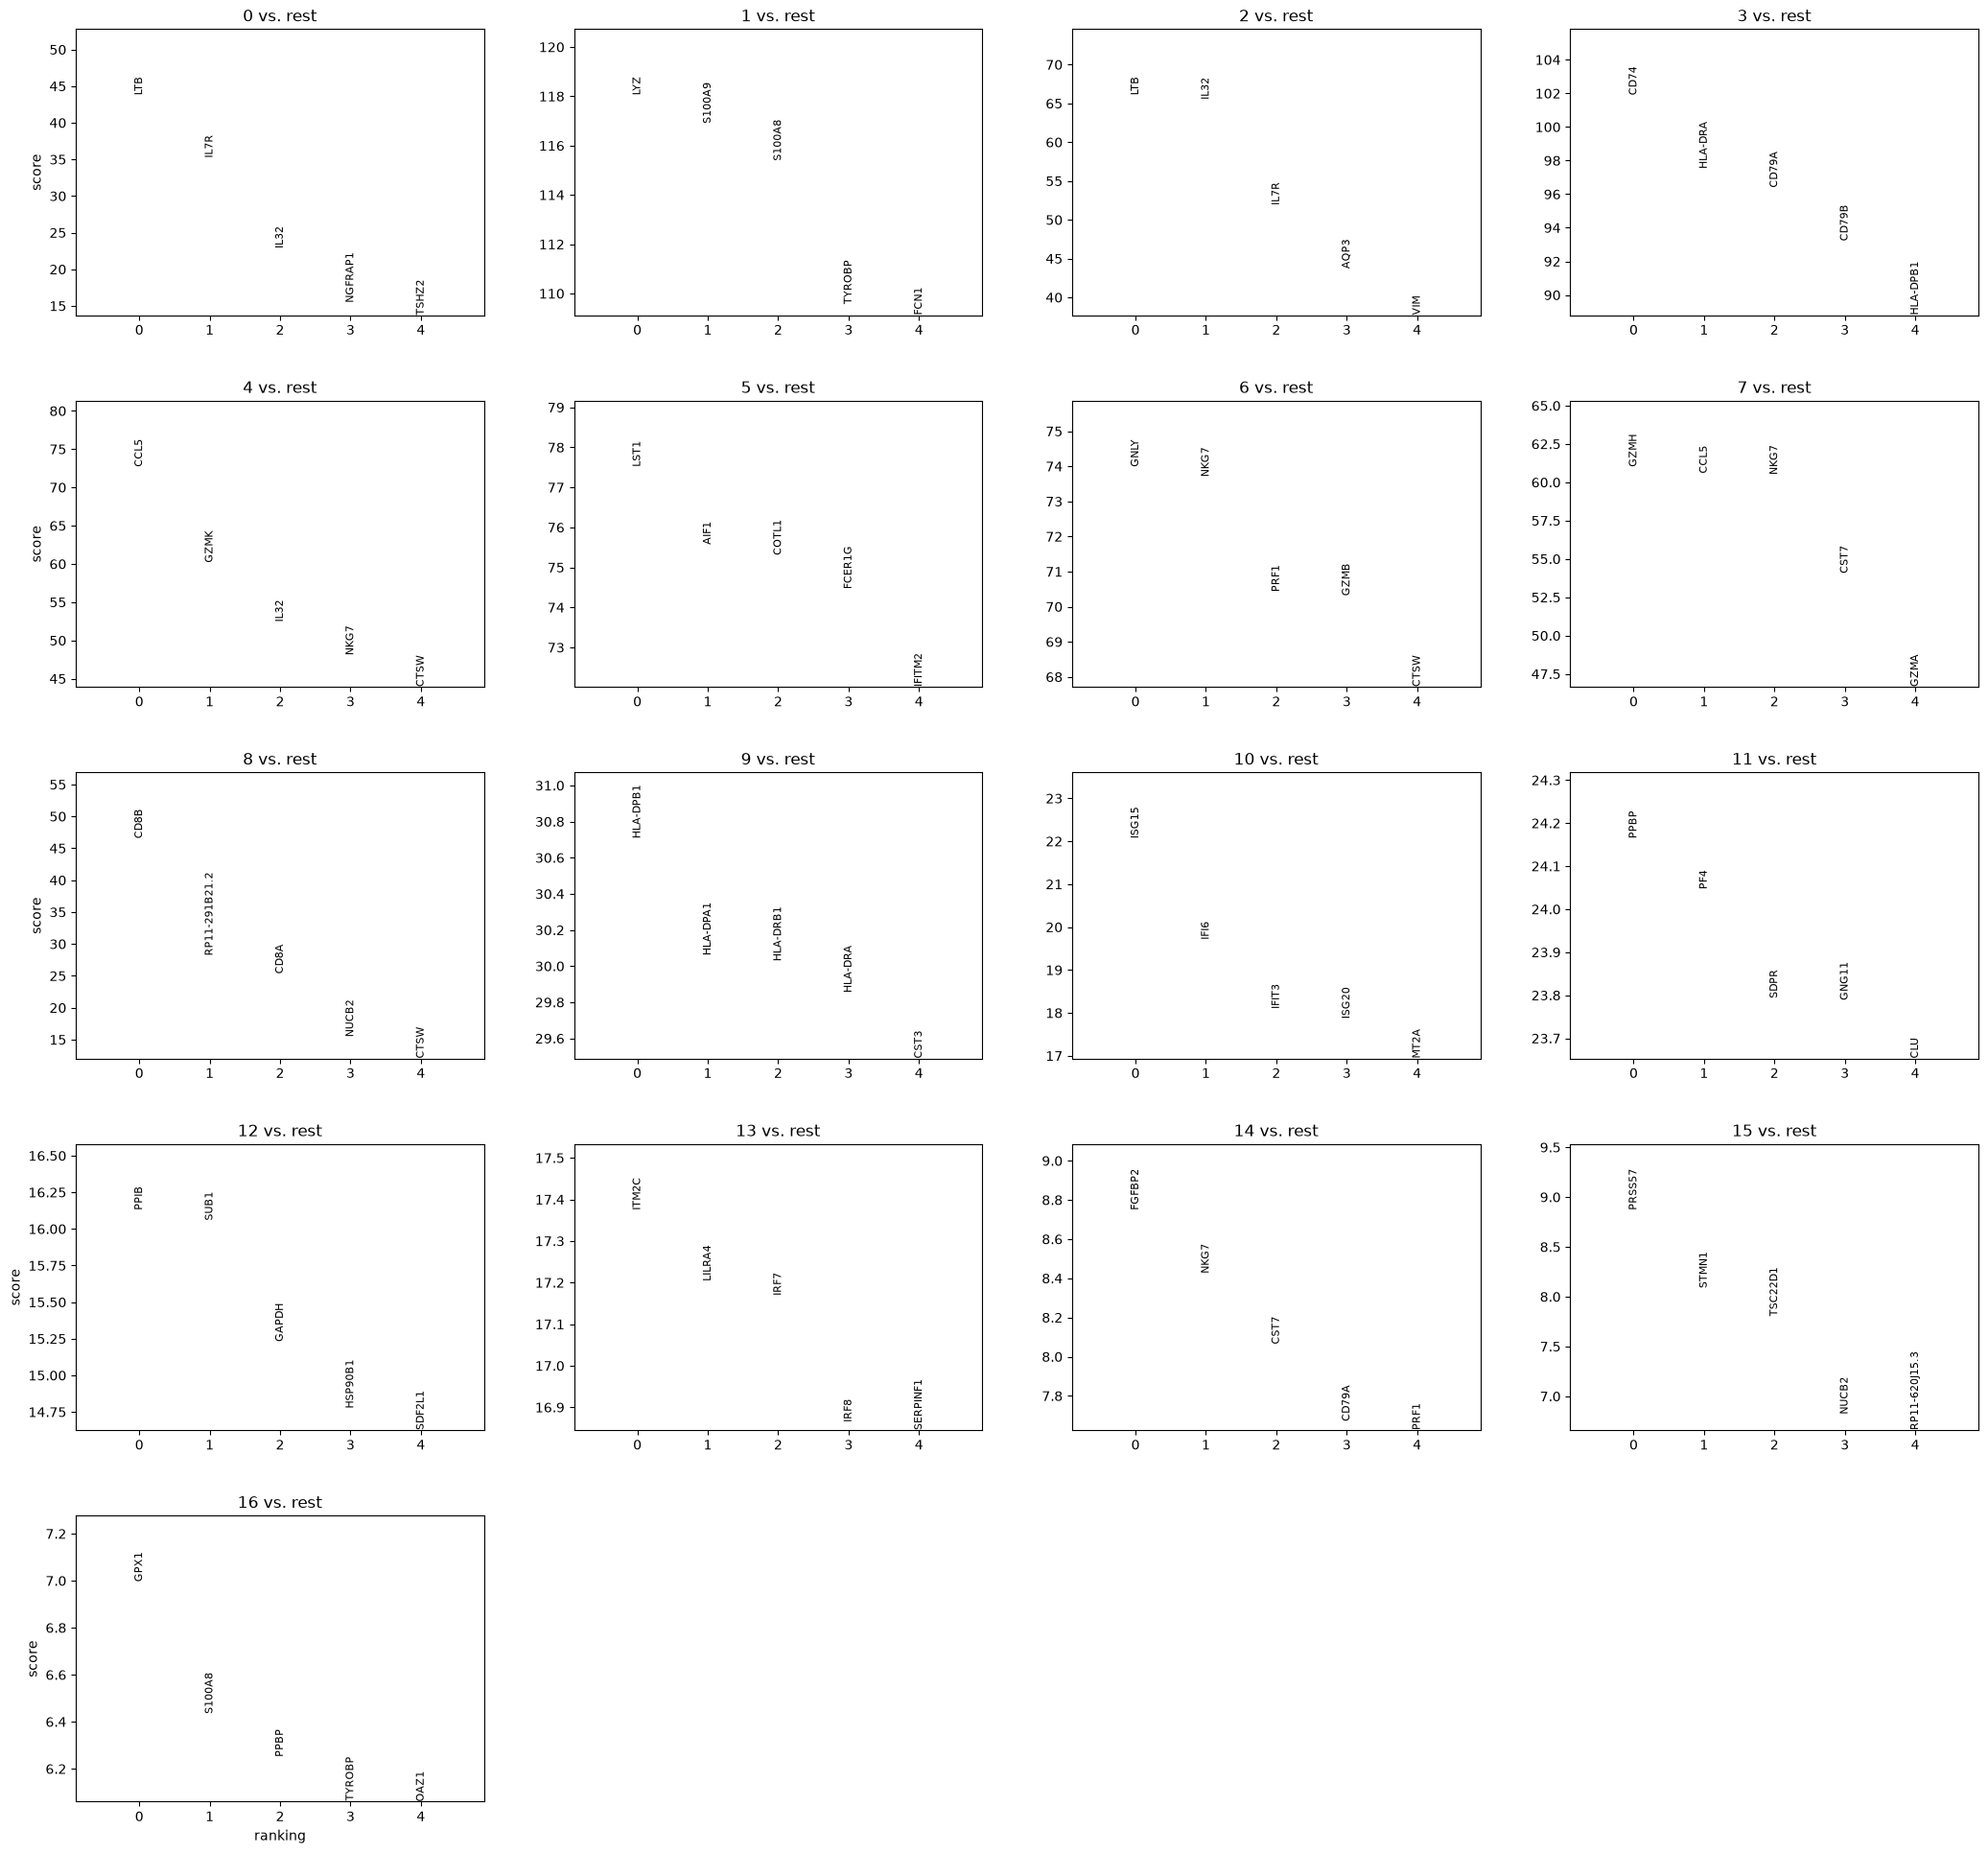

In [21]:
sc.pl.rank_genes_groups(adata, n_genes = 5, sharey = 0)

IDENTIFYING CELL TYPE OF CLUSTERS

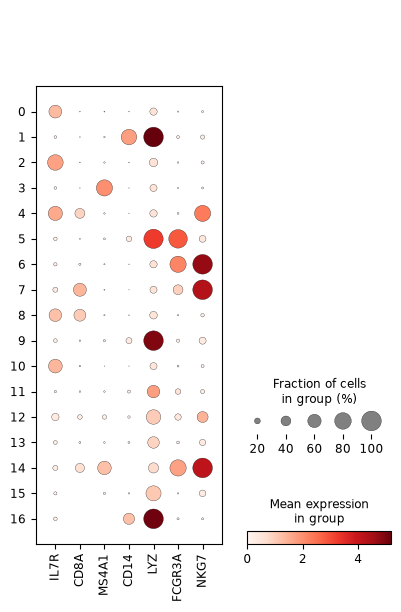

In [22]:
marker_genes = ['IL7R', 'CD8A', 'MS4A1', 'CD14', 'LYZ', 'FCGR3A', 'NKG7']
sc.pl.dotplot(adata, marker_genes, groupby='leiden')

In [23]:
clust_annot = {
    '0': 'CD4 T-cells',
    '1': 'CD14 Monocytes',
    '2': 'CD4 T-cells',
    '3': 'B-Cells',
    '4': 'CD4 T-cells',
    '5': 'FCGR3A monocytes',
    '6': 'NK cells',
    '7': 'CD8 T-cells',
    '8': 'CD8 T-cells',
    '9': 'CD4 T-cells',
    '10': 'Unclear',
    '11': 'Unclear',
    '12': 'Unclear',
    '13': 'Unclear',
    '14': 'Unclear',
    '15': 'CD14 Monocytes'
}
adata.obs['cell_type'] = adata.obs['leiden'].map(clust_annot).astype('category')

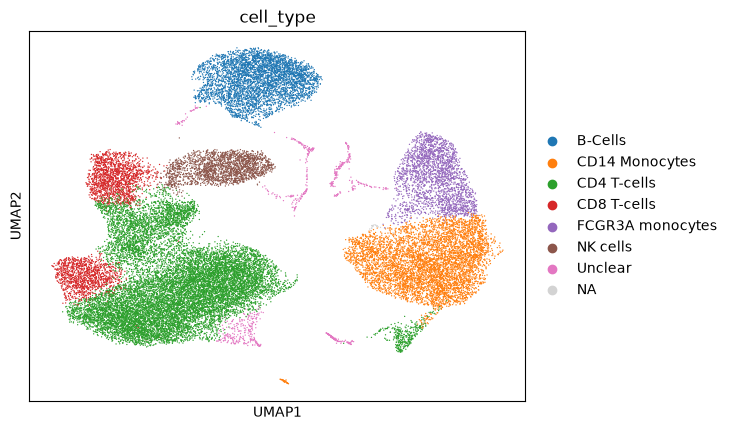

In [24]:
sc.pl.umap(adata, color = 'cell_type')

PREPARING DATA FOR SUPERVISED LEARNING

In [25]:
fork_data.obs['cell_type'] = adata.obs['leiden'].map(clust_annot).astype('category')

In [26]:
# Deleting unused variables
del data
del adata

In [27]:
# Cleaning Garbage
import gc
gc.collect()

13301

In [28]:
"""x = pd.DataFrame(
    fork_data.X,
    columns = fork_data.var_names,
    index = fork_data.obs_names
)"""
x = fork_data.X
y = fork_data.obs['cell_type']

In [29]:
# Splitting Data for training and testing.

from cuml.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

In [30]:
x_train = sc.AnnData(X = x_train)
x_test = sc.AnnData(X = x_test)

In [31]:
# For training data
sc.pp.highly_variable_genes(
    x_train,
    flavor = 'seurat_v3',
    n_top_genes = 2000
)
sc.pp.normalize_total(x_train, target_sum = 10000)
sc.pp.log1p(x_train)


/tmp/ipykernel_57187/3313137443.py:2: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(


In [32]:
# For Training Data 

x_train = x_train[:, x_train.var.highly_variable]

In [33]:
x_train.raw = x_train
x_test.raw = x_test

In [34]:
sc.pp.scale(x_train,max_value = 10)

# For Testing Data

sc.pp.scale(x_test,max_value = 10)

/home/phoenix/anaconda3/envs/cu-gpu/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/phoenix/anaconda3/envs/cu-gpu/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [35]:
x_train = pd.DataFrame(
    x_train.X,
    columns = x_train.var_names,
    index = x_train.obs_names
)

# For Testing Data

x_test = pd.DataFrame(
    x_test.X,
    columns = x_test.var_names,
    index = x_test.obs_names
)

In [36]:
# Ensuring same features in both training and testing datasets.
training_feat = x_train.columns
x_test = x_test[training_feat]

In [37]:
from cuml.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = y_train.astype(str)
y_test = y_test.astype(str)
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
y_test = y_test.replace(7,6)
y_train = y_train.replace(7,6)

SUPERVISED CLASSIFIER TRAINING

LOGISTIC REGRESSION MODEL

In [38]:
from cuml.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [39]:
lr_pred = lr.predict(x_test)

In [40]:
y_t0 = le.inverse_transform(y_test)
lr_pred = le.inverse_transform(lr_pred)

In [41]:
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
print(classification_report(y_t0,lr_pred))

                  precision    recall  f1-score   support

         B-Cells       0.99      0.99      0.99      1282
  CD14 Monocytes       0.97      0.97      0.97      1764
     CD4 T-cells       0.94      0.96      0.95      4404
     CD8 T-cells       0.82      0.79      0.81       856
FCGR3A monocytes       0.93      0.95      0.94       737
        NK cells       0.97      0.95      0.96       651
         Unclear       0.73      0.69      0.71       251

        accuracy                           0.94      9945
       macro avg       0.91      0.90      0.90      9945
    weighted avg       0.94      0.94      0.94      9945



DECISION TREE CLASSIFIER

In [42]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth = None)
dt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [43]:
dt_pred = dt.predict(x_test)

In [44]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1282
           1       0.92      0.89      0.90      1764
           2       0.90      0.90      0.90      4404
           3       0.63      0.69      0.66       856
           4       0.81      0.80      0.81       737
           5       0.92      0.76      0.83       651
           6       0.44      0.65      0.53       251

    accuracy                           0.87      9945
   macro avg       0.80      0.81      0.80      9945
weighted avg       0.87      0.87      0.87      9945



XGBOOST CLASSIFIER

In [45]:
import xgboost as xgb
import cupy as cp
xg = xgb.XGBClassifier(
n_estimators=10000, 
random_state= 42, 
tree_method = "hist", 
device = 'cuda', 
max_depth = None, 
early_stopping_rounds = 50,
learning_rate = 0.01
)

In [46]:
x_test_gpu = cp.array(x_test)
x_train_gpu = cp.array(x_train)
y_train_gpu = cp.array(y_train)
y_test_gpu = cp.array(y_test)
e_set = [(x_test_gpu, y_test_gpu)]

In [47]:
xg.fit(x_train_gpu, y_train_gpu, eval_set = e_set, verbose = 0)
xg_pred = xg.predict(x_test_gpu)

In [48]:
xg_pred1 = xg.predict(x_train_gpu)

In [49]:
xg_pred = le.inverse_transform(xg_pred)
y_t1 = le.inverse_transform(y_test)

In [50]:
print(classification_report(y_train, xg_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2951
           1       1.00      1.00      1.00      4082
           2       1.00      1.00      1.00     10466
           3       1.00      1.00      1.00      2056
           4       1.00      1.00      1.00      1669
           5       1.00      1.00      1.00      1436
           6       1.00      1.00      1.00       543

    accuracy                           1.00     23203
   macro avg       1.00      1.00      1.00     23203
weighted avg       1.00      1.00      1.00     23203



In [51]:
print(classification_report(y_t1, xg_pred))

                  precision    recall  f1-score   support

         B-Cells       0.97      0.99      0.98      1282
  CD14 Monocytes       0.96      0.97      0.96      1764
     CD4 T-cells       0.95      0.97      0.96      4404
     CD8 T-cells       0.87      0.83      0.85       856
FCGR3A monocytes       0.94      0.93      0.93       737
        NK cells       0.95      0.94      0.95       651
         Unclear       0.92      0.57      0.70       251

        accuracy                           0.95      9945
       macro avg       0.94      0.89      0.91      9945
    weighted avg       0.94      0.95      0.94      9945



In [52]:
print(xg.best_iteration)

1311


RANDOM FOREST CLASSIFIER

In [53]:
from cuml.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

In [54]:
rfc.fit(x_train, y_train)
rfc_pred = rfc.predict(x_test)

/tmp/ipykernel_57187/3019437155.py:1: FutureWarning: The default value of 'max_depth' will change from 16 to None (unlimited depth) in release 26.08. To suppress this warning, set 'max_depth' explicitly.
  rfc.fit(x_train, y_train)


In [55]:
print(classification_report(rfc_pred, y_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1285
           1       0.99      0.90      0.94      1937
           2       0.99      0.85      0.92      5082
           3       0.30      0.92      0.45       276
           4       0.81      0.97      0.88       612
           5       0.92      0.94      0.93       640
           6       0.42      0.93      0.58       113

    accuracy                           0.90      9945
   macro avg       0.77      0.93      0.81      9945
weighted avg       0.95      0.90      0.91      9945

